# 04 — Entrenamiento de Modelos
**Proyecto:** PredictRent — Predicción de precios de alquiler en Lima Metropolitana  
**Objetivo:** Entrenar múltiples modelos con diferentes enfoques, documentar cada experimento y registrar sus métricas en validación.

---
## Estrategia de experimentación

Se entrenan **5 modelos** que representan tres familias algorítmicas distintas:

| # | Modelo | Familia | Escalado necesario |
|---|--------|---------|-------------------|
| 1 | Linear Regression | Lineal (baseline) |  Sí |
| 2 | Ridge Regression | Lineal regularizado (L2) |  Sí |
| 3 | Lasso Regression | Lineal regularizado (L1) |  Sí |
| 4 | Random Forest | Ensemble (bagging) |  No |
| 5 | XGBoost | Ensemble (boosting) |  No |

**Hipótesis de partida:** Los modelos de ensemble superarán a los lineales porque existen relaciones no lineales entre el precio y variables como `area_final_m2`, `dormitorios` y `distrito_enc`.

---
## Índice
1. Carga de artefactos
2. Funciones de evaluación
3. Experimento 1 — Linear Regression (baseline)
4. Experimento 2 — Ridge Regression
5. Experimento 3 — Lasso Regression
6. Experimento 4 — Random Forest
7. Experimento 5 — XGBoost
8. Tabla comparativa de resultados
9. Guardado de modelos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, time, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

PROCESSED = '../data/processed/'
MODELS    = '../models/'
FIGURES   = '../reports/figures/'
sns.set_theme(style='whitegrid')
print(' Librerías cargadas')

 Librerías cargadas


---
## 1. Carga de artefactos

In [2]:
X_train = pd.read_csv(f'{PROCESSED}X_train.csv')
X_val   = pd.read_csv(f'{PROCESSED}X_val.csv')
X_test  = pd.read_csv(f'{PROCESSED}X_test.csv')

y_train = pd.read_csv(f'{PROCESSED}y_train.csv')['log_precio'].values
y_val   = pd.read_csv(f'{PROCESSED}y_val.csv')['log_precio'].values
y_test  = pd.read_csv(f'{PROCESSED}y_test.csv')['log_precio'].values

X_train_sc = np.load(f'{PROCESSED}X_train_sc.npy')
X_val_sc   = np.load(f'{PROCESSED}X_val_sc.npy')
X_test_sc  = np.load(f'{PROCESSED}X_test_sc.npy')

FEATURES = joblib.load(f'{MODELS}feature_names.joblib')
FEATURES_SC = joblib.load(f'{MODELS}feature_names_sc.joblib')

print(f'Train:  {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')
print(f'Features: {len(FEATURES_SC)}')

Train:  (2344, 74)  |  Val: (501, 74)  |  Test: (503, 74)
Features: 77


---
## 2. Funciones de evaluación

Definimos una función única que calcula todas las métricas en escala original (USD), revirtiendo el `log1p` con `expm1`.

In [3]:
def evaluar(modelo, X, y_log, nombre_split=''):
    """Evalúa un modelo. y_log está en escala log; convierte a USD para las métricas."""
    y_pred_log = modelo.predict(X)
    
    # Revertir transformación log a USD
    y_real = np.expm1(y_log)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)  # Evitar predicciones negativas
    
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    r2   = r2_score(y_real, y_pred)
    
    if nombre_split:
        print(f'  [{nombre_split}]  RMSE=${rmse:>8,.0f}  MAE=${mae:>7,.0f}  MAPE={mape:>5.2f}%  R²={r2:.4f}')
    
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2}

# Registro global de experimentos
resultados = []
print(' Función de evaluación definida')

 Función de evaluación definida


---
## 3. Experimento 1 — Linear Regression (Baseline)

**Hipótesis:** La regresión lineal establece el piso de performance. Espera un R² bajo porque el precio tiene relaciones no lineales con las features, especialmente el área y el distrito.

**Sin regularización** → propenso a overfitting si hay multicolinealidad entre features.

In [4]:
print('=== Experimento 1: Linear Regression (Baseline) ===')
t0 = time.time()

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

print(f'Tiempo de entrenamiento: {time.time()-t0:.2f}s')
m_tr = evaluar(lr, X_train_sc, y_train, 'Train')
m_va = evaluar(lr, X_val_sc,   y_val,   'Val  ')

# ¿Hay overfitting? Si train >> val en R², sí.
gap = m_tr['r2'] - m_va['r2']
print(f'  Gap R² (train-val): {gap:.4f}  → {" Posible overfitting" if gap > 0.05 else " OK"}')

resultados.append({'modelo': 'Linear Regression', **{f'val_{k}': v for k, v in m_va.items()},
                   **{f'train_{k}': v for k, v in m_tr.items()}})

=== Experimento 1: Linear Regression (Baseline) ===
Tiempo de entrenamiento: 0.01s
  [Train]  RMSE=$     323  MAE=$    173  MAPE=16.87%  R²=0.8053
  [Val  ]  RMSE=$     281  MAE=$    159  MAPE=16.89%  R²=0.8623
  Gap R² (train-val): -0.0570  →  OK


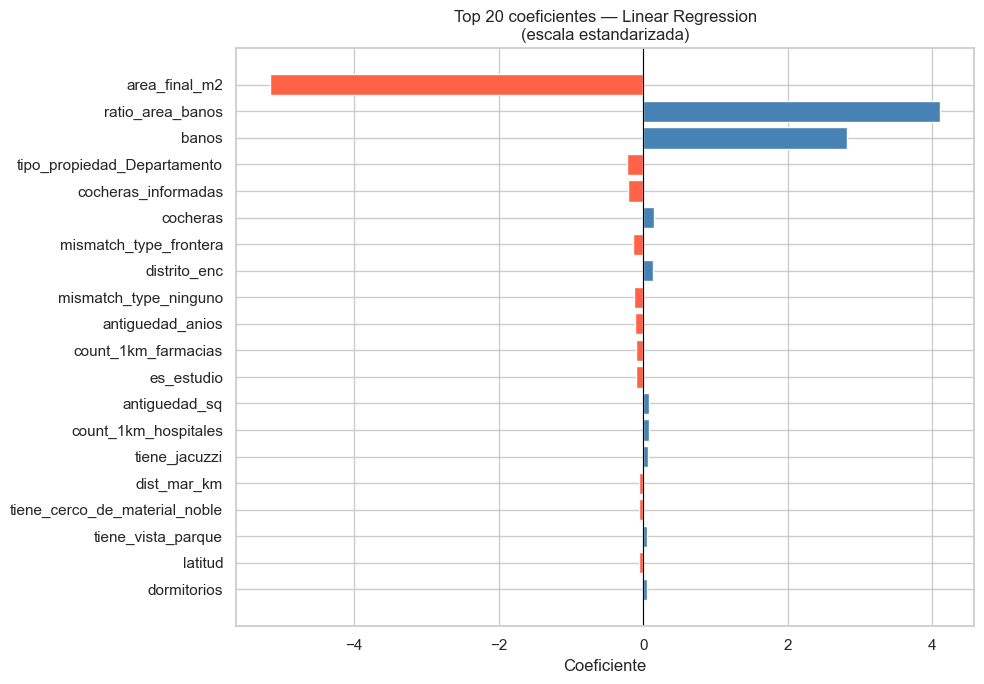

In [5]:
# Visualizar coeficientes más relevantes
coef_df = pd.DataFrame({'feature': FEATURES_SC, 'coef': lr.coef_})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['coef']]
ax.barh(coef_df['feature'][::-1], coef_df['coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 coeficientes — Linear Regression\n(escala estandarizada)', fontsize=12)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.savefig(f'{FIGURES}04_coef_linear.png', dpi=150)
plt.show()

---
## 4. Experimento 2 — Ridge Regression (L2)

**Hipótesis:** Ridge penaliza coeficientes grandes con L2 (`sum(β²)`), lo que reduce el overfitting causado por multicolinealidad entre features como `dormitorios`, `banos` y `area_final_m2`. Esperamos una ligera mejora sobre la regresión lineal pura.

**Hiperparámetro clave:** `alpha` — cuanto mayor, más fuerte la penalización. Buscamos el óptimo con validación cruzada.

=== Experimento 2: Ridge Regression ===
Mejor alpha: 50  (CV-RMSE log: 0.2295)


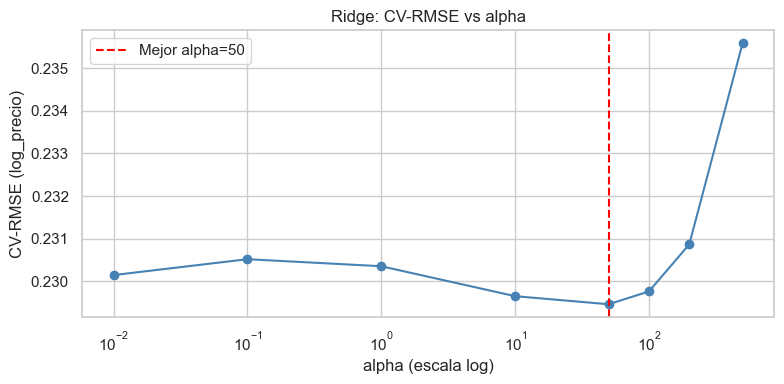

In [6]:
print('=== Experimento 2: Ridge Regression ===')

# Búsqueda de alpha con CV en train
alphas = [0.01, 0.1, 1, 10, 50, 100, 200, 500]
cv_scores = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for a in alphas:
    model = Ridge(alpha=a)
    scores = cross_val_score(model, X_train_sc, y_train, cv=kf,
                             scoring='neg_root_mean_squared_error')
    cv_scores.append(-scores.mean())

best_alpha_ridge = alphas[np.argmin(cv_scores)]
print(f'Mejor alpha: {best_alpha_ridge}  (CV-RMSE log: {min(cv_scores):.4f})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, cv_scores, 'o-', color='steelblue')
ax.axvline(best_alpha_ridge, color='red', linestyle='--', label=f'Mejor alpha={best_alpha_ridge}')
ax.set_xscale('log')
ax.set_title('Ridge: CV-RMSE vs alpha')
ax.set_xlabel('alpha (escala log)')
ax.set_ylabel('CV-RMSE (log_precio)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}04_ridge_alpha.png', dpi=150)
plt.show()

In [7]:
t0 = time.time()
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train_sc, y_train)
print(f'Tiempo de entrenamiento: {time.time()-t0:.2f}s')

m_tr = evaluar(ridge, X_train_sc, y_train, 'Train')
m_va = evaluar(ridge, X_val_sc,   y_val,   'Val  ')
gap = m_tr['r2'] - m_va['r2']
print(f'  Gap R² (train-val): {gap:.4f}  → {" Posible overfitting" if gap > 0.05 else " OK"}')

resultados.append({'modelo': 'Ridge', **{f'val_{k}': v for k, v in m_va.items()},
                   **{f'train_{k}': v for k, v in m_tr.items()}})

Tiempo de entrenamiento: 0.00s
  [Train]  RMSE=$     332  MAE=$    176  MAPE=17.08%  R²=0.7945
  [Val  ]  RMSE=$     294  MAE=$    162  MAPE=16.89%  R²=0.8493
  Gap R² (train-val): -0.0547  →  OK


---
## 5. Experimento 3 — Lasso Regression (L1)

**Hipótesis:** Lasso penaliza con L1 (`sum(|β|)`), lo que puede llevar coeficientes exactamente a cero — es decir, hace **selección automática de features**. Esperamos que Lasso elimine features poco relevantes (como algunas amenities binarias de Properati) y sea más interpretable que Ridge.

In [8]:
print('=== Experimento 3: Lasso Regression ===')

alphas_lasso = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
cv_scores_lasso = []

for a in alphas_lasso:
    model = Lasso(alpha=a, max_iter=5000)
    scores = cross_val_score(model, X_train_sc, y_train, cv=kf,
                             scoring='neg_root_mean_squared_error')
    cv_scores_lasso.append(-scores.mean())

best_alpha_lasso = alphas_lasso[np.argmin(cv_scores_lasso)]
print(f'Mejor alpha: {best_alpha_lasso}  (CV-RMSE log: {min(cv_scores_lasso):.4f})')

t0 = time.time()
lasso = Lasso(alpha=best_alpha_lasso, max_iter=5000)
lasso.fit(X_train_sc, y_train)
print(f'Tiempo de entrenamiento: {time.time()-t0:.2f}s')

m_tr = evaluar(lasso, X_train_sc, y_train, 'Train')
m_va = evaluar(lasso, X_val_sc,   y_val,   'Val  ')
gap = m_tr['r2'] - m_va['r2']
print(f'  Gap R² (train-val): {gap:.4f}  → {" Posible overfitting" if gap > 0.05 else " OK"}')

# Features eliminadas por Lasso
n_zero = (lasso.coef_ == 0).sum()
features_eliminadas = [FEATURES_SC[i] for i, c in enumerate(lasso.coef_) if c == 0]
print(f'  Features llevadas a 0 por Lasso: {n_zero}/{len(FEATURES_SC)}')
print(f'  Eliminadas: {features_eliminadas}')

resultados.append({'modelo': 'Lasso', **{f'val_{k}': v for k, v in m_va.items()},
                   **{f'train_{k}': v for k, v in m_tr.items()}})

=== Experimento 3: Lasso Regression ===
Mejor alpha: 0.001  (CV-RMSE log: 0.2296)
Tiempo de entrenamiento: 0.03s
  [Train]  RMSE=$     331  MAE=$    176  MAPE=17.12%  R²=0.7951
  [Val  ]  RMSE=$     293  MAE=$    162  MAPE=16.96%  R²=0.8494
  Gap R² (train-val): -0.0543  →  OK
  Features llevadas a 0 por Lasso: 22/77
  Eliminadas: ['amenities_count', 'count_1km_bancos', 'count_1km_parqueos', 'ratio_area_banos', 'area_x_amenities', 'antiguedad_sq', 'total_poi_1km', 'tiene_numero_de_pisos', 'tiene_piso_en_el_que_se_encuentra', 'tiene_cerca_a_colegios', 'tiene_cerca_a_parque_a_menos_de_2_cdras', 'tiene_terraza', 'tiene_av_acceso_asfaltada', 'tiene_bano_de_servicio', 'tiene_sistema_contra_incendios', 'tiene_jardines', 'tiene_caseta_de_guardia', 'tiene_frente_a_parque', 'tiene_av_acceso_afirmada', 'tiene_duplex', 'es_estudio', 'es_zona_premium']


---
## 6. Experimento 4 — Random Forest

**Hipótesis:** Random Forest capturará relaciones no lineales que los modelos lineales no pueden. Al combinar cientos de árboles entrenados con subconjuntos aleatorios de datos y features (bagging), reduce la varianza sin aumentar el sesgo significativamente.

**Clave:** No necesita escalado. Hiperparámetros a controlar: `n_estimators`, `max_depth`, `min_samples_leaf`.

In [9]:
print('=== Experimento 4: Random Forest ===')
t0 = time.time()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,          # Árboles completos
    min_samples_leaf=3,      # Evita hojas con muy pocos datos
    max_features=0.6,        # 60% de features por split
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print(f'Tiempo de entrenamiento: {time.time()-t0:.1f}s')

m_tr = evaluar(rf, X_train, y_train, 'Train')
m_va = evaluar(rf, X_val,   y_val,   'Val  ')
gap = m_tr['r2'] - m_va['r2']
print(f'  Gap R² (train-val): {gap:.4f}  → {" Posible overfitting" if gap > 0.05 else " OK"}')

resultados.append({'modelo': 'Random Forest', **{f'val_{k}': v for k, v in m_va.items()},
                   **{f'train_{k}': v for k, v in m_tr.items()}})

=== Experimento 4: Random Forest ===
Tiempo de entrenamiento: 0.8s
  [Train]  RMSE=$     194  MAE=$     87  MAPE= 8.06%  R²=0.9296
  [Val  ]  RMSE=$     301  MAE=$    160  MAPE=16.52%  R²=0.8412
  Gap R² (train-val): 0.0884  →  Posible overfitting


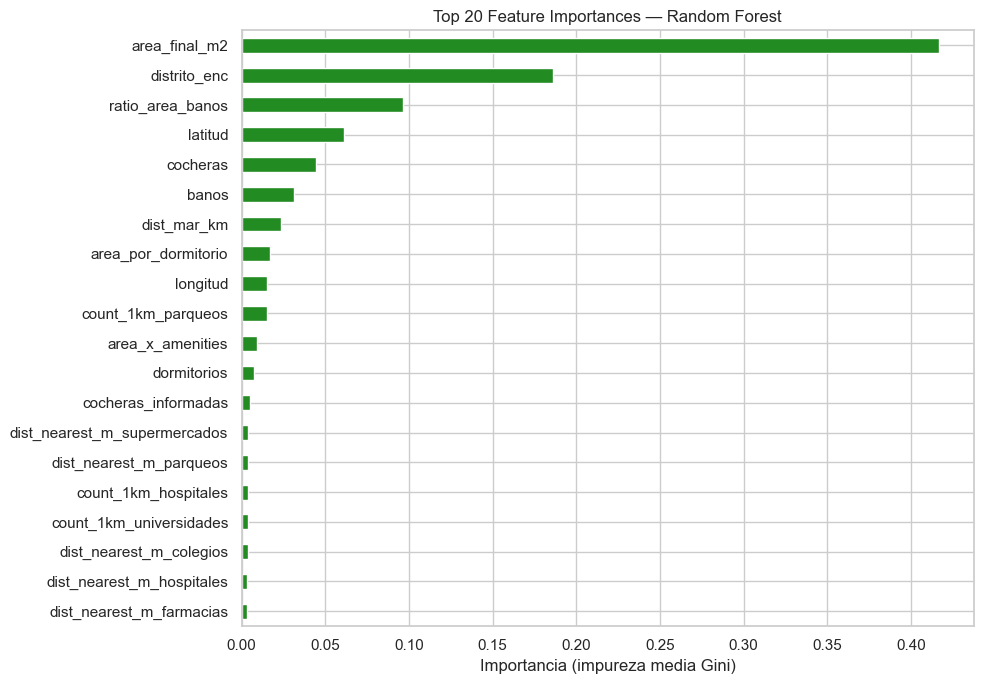

In [10]:
# Feature Importance de Random Forest
fi_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
fi_rf[::-1].plot(kind='barh', ax=ax, color='forestgreen')
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=12)
ax.set_xlabel('Importancia (impureza media Gini)')
plt.tight_layout()
plt.savefig(f'{FIGURES}04_fi_rf.png', dpi=150)
plt.show()

---
## 7. Experimento 5 — XGBoost

**Hipótesis:** XGBoost (Extreme Gradient Boosting) construye árboles de forma secuencial, donde cada árbol corrige los errores del anterior. A diferencia de Random Forest (paralelismo), XGBoost aprende iterativamente del gradiente de la función de pérdida. Esperamos que sea el modelo más preciso.

**Parámetros clave:**
- `learning_rate`: cuanto menor, más lento aprende pero más fino el ajuste (controla con `n_estimators`).
- `max_depth`: profundidad máxima de cada árbol (controla complejidad).
- `subsample` y `colsample_bytree`: fracción de datos y features por árbol → regularización.

In [11]:
print('=== Experimento 5: XGBoost ===')
t0 = time.time()

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,       # Regularización L1
    reg_lambda=1.0,      # Regularización L2
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
# Early stopping: para el entrenamiento si la val no mejora en 30 rondas
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print(f'Tiempo de entrenamiento: {time.time()-t0:.1f}s')

m_tr = evaluar(xgb_model, X_train, y_train, 'Train')
m_va = evaluar(xgb_model, X_val,   y_val,   'Val  ')
gap = m_tr['r2'] - m_va['r2']
print(f'  Gap R² (train-val): {gap:.4f}  → {" Posible overfitting" if gap > 0.05 else " OK"}')

resultados.append({'modelo': 'XGBoost', **{f'val_{k}': v for k, v in m_va.items()},
                   **{f'train_{k}': v for k, v in m_tr.items()}})

=== Experimento 5: XGBoost ===
Tiempo de entrenamiento: 1.2s
  [Train]  RMSE=$      55  MAE=$     33  MAPE= 3.45%  R²=0.9944
  [Val  ]  RMSE=$     293  MAE=$    155  MAPE=15.78%  R²=0.8501
  Gap R² (train-val): 0.1442  →  Posible overfitting


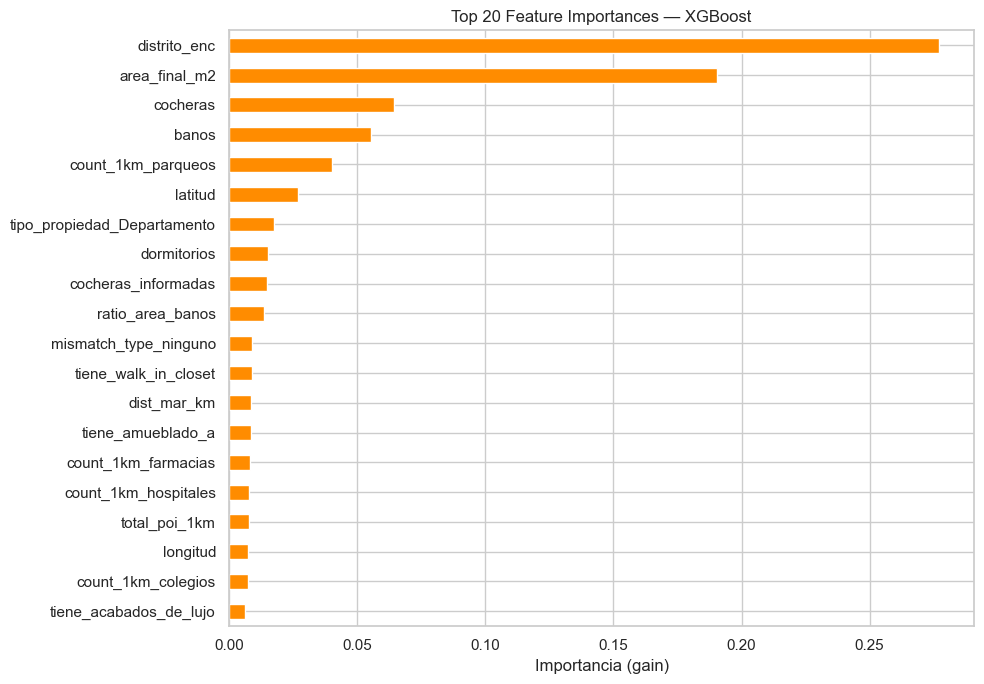

In [12]:
# Feature Importance XGBoost
fi_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
fi_xgb[::-1].plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 20 Feature Importances — XGBoost', fontsize=12)
ax.set_xlabel('Importancia (gain)')
plt.tight_layout()
plt.savefig(f'{FIGURES}04_fi_xgb.png', dpi=150)
plt.show()

---
## 8. Tabla comparativa de resultados

In [13]:
res_df = pd.DataFrame(resultados)

print('=== COMPARACIÓN DE MÉTRICAS EN VALIDACIÓN ===')
display_cols = ['modelo', 'val_rmse', 'val_mae', 'val_mape', 'val_r2']
val_table = res_df[display_cols].copy()
val_table.columns = ['Modelo', 'RMSE (USD)', 'MAE (USD)', 'MAPE (%)', 'R²']
val_table = val_table.sort_values('R²', ascending=False).reset_index(drop=True)
val_table['RMSE (USD)'] = val_table['RMSE (USD)'].apply(lambda x: f'${x:,.0f}')
val_table['MAE (USD)']  = val_table['MAE (USD)'].apply(lambda x: f'${x:,.0f}')
val_table['MAPE (%)']   = val_table['MAPE (%)'].apply(lambda x: f'{x:.2f}%')
val_table['R²']         = val_table['R²'].apply(lambda x: f'{x:.4f}')
display(val_table)

=== COMPARACIÓN DE MÉTRICAS EN VALIDACIÓN ===


,Modelo,RMSE (USD),MAE (USD),MAPE (%),R²
0,Linear Regression,$281,$159,16.89%,0.8623
1,XGBoost,$293,$155,15.78%,0.8501
2,Lasso,$293,$162,16.96%,0.8494
3,Ridge,$294,$162,16.89%,0.8493
4,Random Forest,$301,$160,16.52%,0.8412


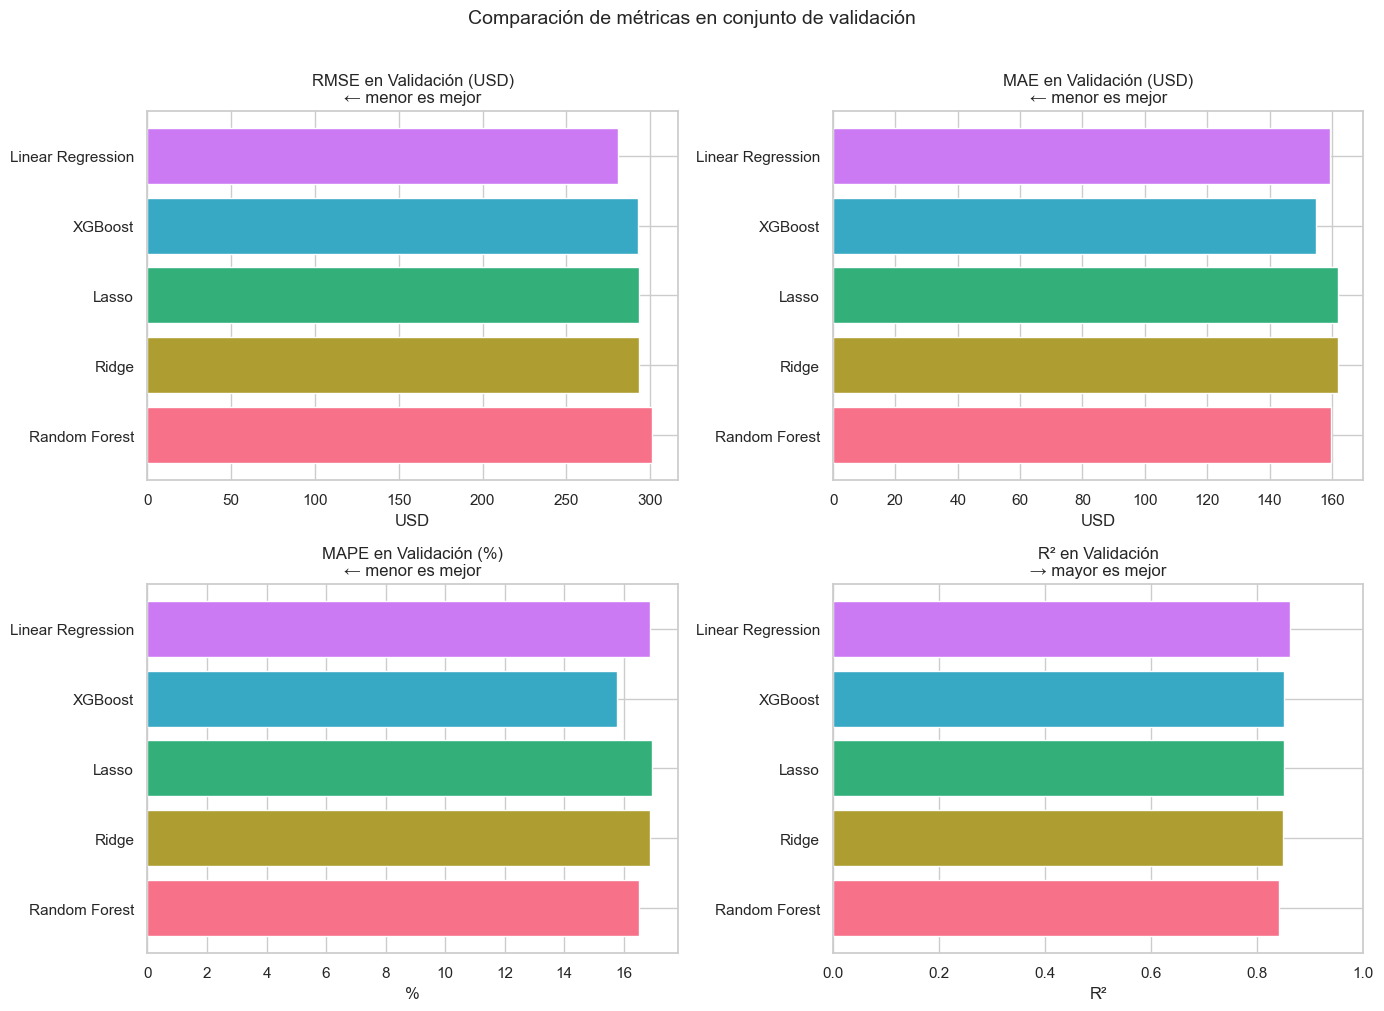

In [14]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
res_sorted = res_df.sort_values('val_r2', ascending=False)
modelos = res_sorted['modelo']
palette = sns.color_palette('husl', len(modelos))

# RMSE
axes[0,0].barh(modelos[::-1], res_sorted['val_rmse'][::-1], color=palette)
axes[0,0].set_title('RMSE en Validación (USD)\n← menor es mejor')
axes[0,0].set_xlabel('USD')

# MAE  
axes[0,1].barh(modelos[::-1], res_sorted['val_mae'][::-1], color=palette)
axes[0,1].set_title('MAE en Validación (USD)\n← menor es mejor')
axes[0,1].set_xlabel('USD')

# MAPE
axes[1,0].barh(modelos[::-1], res_sorted['val_mape'][::-1], color=palette)
axes[1,0].set_title('MAPE en Validación (%)\n← menor es mejor')
axes[1,0].set_xlabel('%')

# R²
axes[1,1].barh(modelos[::-1], res_sorted['val_r2'][::-1], color=palette)
axes[1,1].set_title('R² en Validación\n→ mayor es mejor')
axes[1,1].set_xlabel('R²')
axes[1,1].set_xlim(0, 1)

plt.suptitle('Comparación de métricas en conjunto de validación', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}04_comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

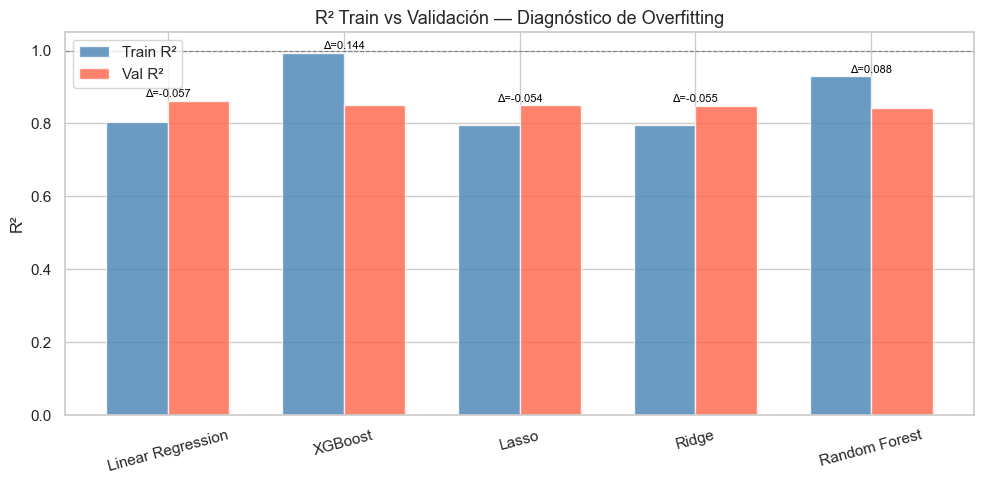

In [15]:
# Gráfico: train vs val R² (detectar overfitting)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(res_df))
width = 0.35
res_sorted2 = res_df.sort_values('val_r2', ascending=False)

bars1 = ax.bar(x - width/2, res_sorted2['train_r2'], width, label='Train R²', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, res_sorted2['val_r2'],   width, label='Val R²',   color='tomato',    alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(res_sorted2['modelo'], rotation=15)
ax.set_ylabel('R²')
ax.set_ylim(0, 1.05)
ax.set_title('R² Train vs Validación — Diagnóstico de Overfitting', fontsize=13)
ax.legend()
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

# Anotar el gap
for i, row in enumerate(res_sorted2.itertuples()):
    gap = row.train_r2 - row.val_r2
    ax.text(i, max(row.train_r2, row.val_r2) + 0.01, f'Δ={gap:.3f}',
            ha='center', fontsize=8, color='black')

plt.tight_layout()
plt.savefig(f'{FIGURES}04_overfitting_diagnostico.png', dpi=150)
plt.show()

---
## 9. Guardado de modelos

In [16]:
joblib.dump(lr,        f'{MODELS}01_linear_regression.joblib')
joblib.dump(ridge,     f'{MODELS}02_ridge.joblib')
joblib.dump(lasso,     f'{MODELS}03_lasso.joblib')
joblib.dump(rf,        f'{MODELS}04_random_forest.joblib')
joblib.dump(xgb_model, f'{MODELS}05_xgboost.joblib')

# Guardar tabla de resultados
res_df.to_csv(f'{PROCESSED}resultados_modelos.csv', index=False)

print('- Modelos guardados:')
import os
for f in sorted(os.listdir(MODELS)):
    size = os.path.getsize(f'{MODELS}{f}') / 1024
    print(f'   {f:<45} {size:>8.1f} KB')

- Modelos guardados:
   01_linear_regression.joblib                        1.7 KB
   02_ridge.joblib                                    1.1 KB
   03_lasso.joblib                                    1.2 KB
   04_random_forest.joblib                        17371.9 KB
   05_xgboost.joblib                               1814.1 KB
   feature_names.joblib                               1.6 KB
   feature_names_sc.joblib                            1.7 KB
   features_log_transformed.joblib                    0.4 KB
   modelo_final.joblib                                3.6 KB
   outlier_caps.joblib                                0.4 KB
   scaler.joblib                                      2.2 KB
   target_enc_distrito.joblib                         2.9 KB
